# Homework 09 - Feature Engineering

**Course:** FRE 5040 Applied Financial Engineering
**Dataset:** one year of daily closes for the three funds in the Portfolio Drift Monitor
(VTI 60%, VXUS 30%, BND 10%), the same file Stage 08 profiled.

Six engineered features. Every one of them names the Stage 08 finding it came from,
because a feature invented without a reason is the thing the reading warns against:
"Every feature idea should come from patterns noticed in EDA."

| Section | Requirement |
|---|---|
| 2 | choosing the target, with evidence |
| 3 to 8 | six features, code plus rationale (three required) |
| 7 | **categorical encoding**, with the argument for the choice |
| 9 | correlation check against the target, and what it says |
| 10 | what Stage 08's own gate rejects |
| 11 | look-ahead test, including a deliberate failure |
| 12 | summary and handoff to Stage 10 |

Helper module: `src/features.py`. Stage 08's `src/eda.py` is also imported, so its
column gate can be run against this stage's output.

Run order: Kernel -> Restart Kernel and Run All Cells.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy pandas scipy matplotlib seaborn

## 0. Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import features as F
from src.eda import flag_columns

sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

RAW = Path('data/raw')
PROC = Path('data/processed')
PROC.mkdir(parents=True, exist_ok=True)

TARGET_WEIGHTS = {'VTI': 0.60, 'VXUS': 0.30, 'BND': 0.10}
TICKERS = list(TARGET_WEIGHTS)
HORIZON = 21          # trading days, chosen in section 2

print('working from:', ROOT.name)
print('pandas', pd.__version__)

working from: homework09
pandas 2.3.3


## 1. The data, and the panel everything is built on

Same real project data as Stage 08, not the starter's synthetic customers. The features
that matter here are about drift over time, and a synthetic frame with no time axis
cannot carry any of them.

Weights follow the project's convention: buy the 60/30/10 target on day one, never
rebalance, so drift is what the market does to a portfolio left alone.

In [3]:
prices = pd.read_csv(RAW / 'portfolio_prices.csv', parse_dates=['date'])

wide = prices.pivot(index='date', columns='ticker', values='close')[TICKERS]
targets = np.array([TARGET_WEIGHTS[t] for t in TICKERS])
shares = (1_000_000 * targets) / wide.iloc[0].to_numpy()
values = wide.to_numpy() * shares
weights_df = pd.DataFrame(values / values.sum(axis=1, keepdims=True),
                          index=wide.index, columns=TICKERS)

drift_long = ((weights_df - targets) * 100).reset_index().melt(
    id_vars='date', var_name='ticker', value_name='drift_pp')

assert np.allclose(weights_df.iloc[0], targets), 'day 0 must sit on target'
print(f'{len(wide)} trading days, {len(drift_long)} fund-days')
drift_long.head()

251 trading days, 753 fund-days


,date,ticker,drift_pp
0,2025-08-29,VTI,0.000000
1,2025-09-02,VTI,-0.008121
2,2025-09-03,VTI,0.035780
3,2025-09-04,VTI,0.151162
4,2025-09-05,VTI,-0.039599


## 2. Choosing the target before choosing the features

The rubric asks for a correlation check against "the target variable", and this project
does not have one yet: the monitor reports, it does not predict. So the target has to be
defined here, and the choice is not free.

The obvious candidate, `flag`, is unusable. Stage 08 found it is 100% green across all
753 fund-days, so as a label it has one class.

The next candidate is the drift itself, some number of days ahead. The question is how
many.

In [4]:
horizons = [1, 5, 21, 63]
rows = []
base = F.drift_features(drift_long, TARGET_WEIGHTS, slope_windows=())
for h in horizons:
    frame = F.make_forward_target(base, horizon=h)
    col = f'y_absdrift_fwd_{h}'
    row = {'horizon_trading_days': h}
    pair = frame[['abs_drift', col]].dropna()
    row['pooled_r'] = pair['abs_drift'].corr(pair[col])
    for t in TICKERS:
        p = frame[frame['ticker'] == t][['abs_drift', col]].dropna()
        row[t] = p['abs_drift'].corr(p[col])
    rows.append(row)

horizon_table = pd.DataFrame(rows).set_index('horizon_trading_days').round(3)
horizon_table

,pooled_r,VTI,VXUS,BND
horizon_trading_days,,,,
1,0.979,0.949,0.976,0.992
5,0.913,0.774,0.904,0.965
21,0.689,0.273,0.656,0.865
63,0.235,-0.309,0.057,0.749


**What?** Today's absolute drift correlates with tomorrow's at 0.979 pooled, and 0.992
for BND. At 21 trading days that falls to 0.689, and at 63 to 0.235.

**So what?** A one-day-ahead target is very nearly the feature itself. Any model would
score above 0.95 by predicting "the same as today" and would have learned nothing about
drift. That number is Stage 08's trend finding arriving as a modelling constraint: a
series dominated by a trend is trivially predictable one step ahead, and the triviality
scales with how short the step is.

63 days is the opposite problem. VTI's correlation goes *negative* (-0.309), which means
a quarter ahead the current level is close to useless and the sample is down to 504
usable rows.

**Now what?** The target is **absolute drift 21 trading days ahead**, about one calendar
month. It is far enough out that the current level explains under half the variance
pooled, which leaves something for the other features to do, and it is a horizon that
means something operationally: a month is enough warning for the principal to decide
whether to rebalance.

In [5]:
TARGET = f'y_absdrift_fwd_{HORIZON}'
print('target:', TARGET)

target: y_absdrift_fwd_21


## 3. Feature 1 - `drift_rel`, the drift in relative units

**Where it comes from.** Stage 07 recorded an open problem in `docs/outliers.md`: a
single percentage-point threshold treats all three funds as equivalent. Stage 08 sized
it. BND's worst drift, 1.769pp, is 17.7% of its 10% target. VTI's worst, 1.553pp, is
2.6% of its 60% target. Nearly the same number of percentage points, seven times apart
in relative terms.

**The hypothesis.** Distance from target expressed as a share of that target is the
quantity that means the same thing for all three funds, so it should be the more
consistent predictor across funds.

In [6]:
feat = F.drift_features(drift_long, TARGET_WEIGHTS, slope_windows=(21, 63))
feat[['date', 'ticker', 'drift_pp', 'abs_drift', 'drift_rel', 'abs_drift_rel']].head()

,date,ticker,drift_pp,abs_drift,drift_rel,abs_drift_rel
0,2025-08-29,BND,0.000000,0.000000,0.000000,0.000000
1,2025-09-02,BND,0.014004,0.014004,0.140043,0.140043
2,2025-09-03,BND,0.011644,0.011644,0.116437,0.116437
3,2025-09-04,BND,-0.019356,0.019356,-0.193559,0.193559
4,2025-09-05,BND,0.014556,0.014556,0.145557,0.145557


In [7]:
# Within one fund the two are the same information: drift_rel is drift_pp divided by a
# constant. Verify that rather than assume it.
for t in TICKERS:
    p = feat[feat['ticker'] == t]
    print(f'{t:<5} corr(abs_drift, abs_drift_rel) = {p["abs_drift"].corr(p["abs_drift_rel"]):.6f}')

VTI   corr(abs_drift, abs_drift_rel) = 1.000000
VXUS  corr(abs_drift, abs_drift_rel) = 1.000000
BND   corr(abs_drift, abs_drift_rel) = 1.000000


In [8]:
# So the question is not which feature is better. It is which UNIT the target is in.
# Build both targets and cross them against both features.
unit = F.make_forward_target(feat, horizon=HORIZON, col='drift_pp',
                             absolute=True, out_col='y_pp')
unit = F.make_forward_target(unit, horizon=HORIZON, col='drift_rel',
                             absolute=True, out_col='y_rel')

grid = []
for f_col in ['abs_drift', 'abs_drift_rel']:
    row = {'feature': f_col}
    for t_col in ['y_pp', 'y_rel']:
        pair = unit[[f_col, t_col]].dropna()
        row[t_col] = pair[f_col].corr(pair[t_col])
    grid.append(row)
unit_matrix = pd.DataFrame(grid).set_index('feature').round(3)
unit_matrix

,y_pp,y_rel
feature,,
abs_drift,0.689,0.523
abs_drift_rel,0.621,0.906


**Correlation check.** Within each fund the two features correlate at exactly 1.000000,
so they carry identical information. Across funds they do not, and the cross table shows
why:

|  | target in pp | target in % of target weight |
|---|---|---|
| `abs_drift` (pp) | **0.689** | 0.523 |
| `abs_drift_rel` (relative) | 0.621 | **0.906** |

**What this says.** Each feature predicts its own unit best, and the diagonal is much
stronger in the relative corner. Drift measured relative to target is substantially more
predictable a month out (0.906) than drift measured in percentage points (0.689).

**So what?** This is not a feature-engineering result, it is a *policy* result that
feature engineering happened to surface. The unit the threshold is written in is the
unit the model should predict, and Stage 07 left that unit open as a decision for the
principal. This adds evidence to that decision: the relative formulation is the more
internally consistent description of what the portfolio does. It is worth putting in
front of the principal alongside the Stage 07 note.

**Now what?** Carry both. `abs_drift` matches the policy as written today;
`abs_drift_rel` matches the policy as it might sensibly be rewritten. Stage 10 can score
against either, and the pair is the evidence for the argument.

## 4. Feature 2 - the rate of drift: `drift_chg_1` and `drift_slope_21` / `drift_slope_63`

**Where it comes from.** Stage 08's central finding: BND's drift correlates with time at
-0.93, so 86% of its variation is a straight line. The written instruction to this stage
was "features go on the *rate* of drift, not the level", because a trended level makes a
lagged level nearly as good a predictor as the current one, which adds nothing.

**The hypothesis.** Three ways to measure a rate, at three timescales. The first
difference is the instantaneous rate. The 21-day and 63-day rolling slopes are the same
line Stage 08 fitted to the whole year, refitted to a moving window, so a model can see
the trend *steepening* rather than only that it exists.

Every window is right-aligned, so the value at row *t* is fitted to rows *t-w+1* through
*t*. Section 11 tests that claim.

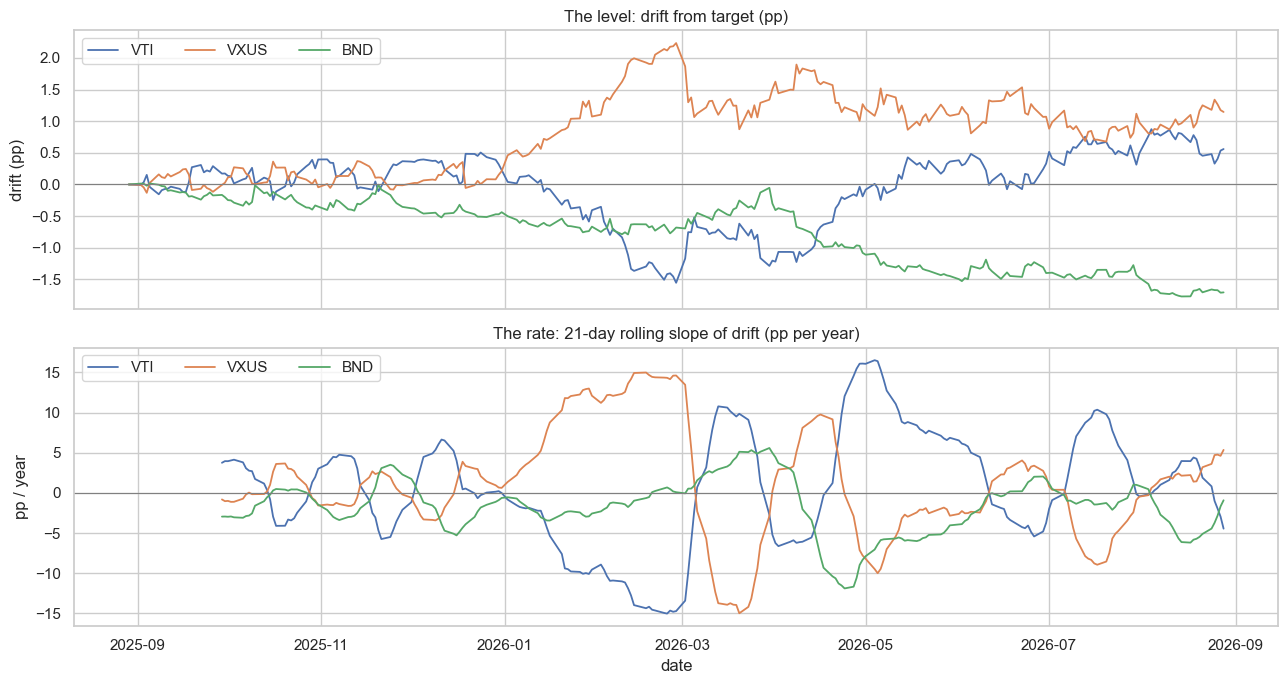

       drift_chg_1        drift_slope_21        drift_slope_63       
              mean    std           mean    std           mean    std
ticker                                                               
BND         -0.007  0.067         -1.746  3.352         -1.657  1.692
VTI          0.002  0.123          0.719  7.078          0.497  4.343
VXUS         0.005  0.133          1.028  6.619          1.160  3.513


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for t in TICKERS:
    p = feat[feat['ticker'] == t].set_index('date')
    axes[0].plot(p.index, p['drift_pp'], linewidth=1.3, label=t)
    axes[1].plot(p.index, p['drift_slope_21'], linewidth=1.3, label=t)

axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].set_title('The level: drift from target (pp)')
axes[0].set_ylabel('drift (pp)')
axes[0].legend(ncol=3, loc='upper left')

axes[1].axhline(0, color='grey', linewidth=0.8)
axes[1].set_title('The rate: 21-day rolling slope of drift (pp per year)')
axes[1].set_ylabel('pp / year')
axes[1].set_xlabel('date')
axes[1].legend(ncol=3, loc='upper left')

fig.tight_layout()
plt.show()

print(feat.groupby('ticker')[['drift_chg_1', 'drift_slope_21', 'drift_slope_63']]
        .agg(['mean', 'std']).round(3).to_string())

**What the plot shows.** The top panel is three lines that mostly go one way. The bottom
panel oscillates around zero and crosses it repeatedly. That contrast is the feature
working: the level is a trend, the rate is a signal about how fast that trend is running
right now.

BND's rolling slope stays below zero for long stretches, which is the ratchet Stage 08
described. VTI's crosses zero constantly, which is why Stage 08 measured its whole-year
correlation with time at only 0.175.

**A cost worth naming.** The 21-day slope is NaN for the first 20 rows of each fund and
the 63-day slope for the first 62. Section 10 puts a number on that and decides what to
do about it.

## 5. Feature 3 - `vol_21`, realized volatility

**Where it comes from.** Stage 08's rolling-volatility plot: VTI moved between 6% and
21% annualized, VXUS between 8% and 29%, in visible clusters rather than at a level. A
clustered series is one whose current value says something about its near future, which
is what makes it a feature instead of a constant.

**The hypothesis.** A fund in a high-volatility regime covers more ground per unit of
time, so its weight moves further from target. Volatility should lead drift.

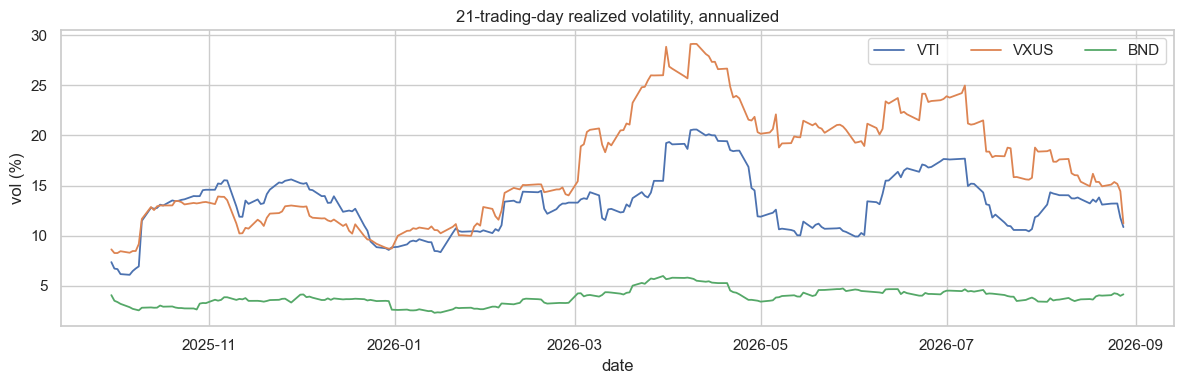

         min    50%    max
ticker                    
BND     2.28   3.71   5.96
VTI     6.08  13.20  20.59
VXUS    8.25  15.50  29.16


In [10]:
vol = F.volatility_feature(prices, window=21)[['date', 'ticker', 'ret_1', 'vol_21']]
feat = feat.merge(vol, on=['date', 'ticker'], how='left')

fig, ax = plt.subplots(figsize=(12, 4))
for t in TICKERS:
    p = feat[feat['ticker'] == t].set_index('date')
    ax.plot(p.index, p['vol_21'], linewidth=1.3, label=t)
ax.set_title('21-trading-day realized volatility, annualized')
ax.set_ylabel('vol (%)'); ax.set_xlabel('date')
ax.legend(ncol=3)
fig.tight_layout()
plt.show()

print(feat.groupby('ticker')['vol_21'].describe()[['min', '50%', 'max']].round(2).to_string())

**Correlation check comes in section 9**, but the headline is worth stating here: against
the 21-day forward target, `vol_21` correlates at **+0.567 for BND** and **-0.227 for
VTI**. Same feature, opposite sign, depending on the fund.

**So what?** That sign flip is the argument for keeping the fund identity in the model.
A single pooled coefficient on volatility would average +0.57 and -0.23 into something
near zero and conclude volatility does not matter. It matters; it just matters
differently, and the model needs to be allowed to say so. That is section 7's job.

## 6. Feature 4 - `eq_bond_spread_21`, the mechanism

**Where it comes from.** Stage 08 did not only observe the drift, it traced it: over the
window VTI returned +19.2%, VXUS +22.6% and BND -2.0%. A portfolio bought at target and
left alone drifts at a rate set by exactly that gap.

**The hypothesis.** Every other feature here *describes* the drift. This one describes
what is causing it, so it should hold up better out of sample than a feature that only
happens to move alongside the thing being predicted.

This is portfolio-level, so it takes the same value for all three funds on a date. That
is correct: it is a property of the market that day, not of a fund.

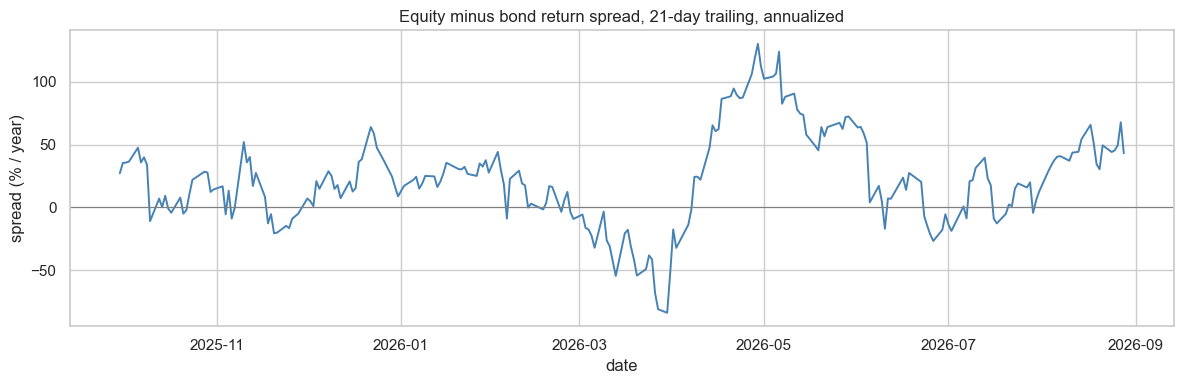

count    690.00
mean      22.09
std       36.48
min      -83.87
25%       -1.65
50%       20.49
75%       40.49
max      130.29


In [11]:
spread = F.equity_bond_spread(prices, TARGET_WEIGHTS, bond='BND', window=21)
feat = feat.merge(spread, on='date', how='left')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(feat['date'].unique(),
        feat.drop_duplicates('date').sort_values('date')['eq_bond_spread_21'],
        color='steelblue', linewidth=1.4)
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_title('Equity minus bond return spread, 21-day trailing, annualized')
ax.set_ylabel('spread (% / year)'); ax.set_xlabel('date')
fig.tight_layout()
plt.show()

print(feat['eq_bond_spread_21'].describe().round(2).to_string())

**What?** The spread is positive most of the window, averaging about +22% annualized,
with excursions in both directions.

**So what?** A spread that is positive on average and rarely negative is precisely the
condition that produces a one-way ratchet rather than an oscillation. The feature and
the Stage 08 finding are two views of the same fact, which is the point: the feature
encodes a mechanism rather than a coincidence.

## 7. Feature 5 - encoding the fund identifier (the required categorical)

`ticker` is the categorical column in this dataset. The lecture gives three ways to
encode it, and says the choice matters. On this dataset the choice is decided by a single
number that Stage 08 already produced.

**Stage 08's categorical profile: 251 / 251 / 251, exactly.** Stage 06's
`drop_incomplete_days` keeps only dates that have a close for every fund, so the three
funds have identical row counts by construction.

In [12]:
enc = F.encode_ticker(feat, 'onehot')
enc = F.encode_ticker(enc, 'label')
enc = F.encode_ticker(enc, 'frequency')
enc = F.encode_ticker(enc, 'target_weight', target_weights=TARGET_WEIGHTS)

print(enc.groupby('ticker')[['ticker_label', 'ticker_freq', 'ticker_target',
                             'ticker_VTI', 'ticker_VXUS', 'ticker_BND']]
         .first().to_string())
print()
print('distinct values produced by each encoding')
for c in ['ticker_freq', 'ticker_label', 'ticker_target']:
    print(f'  {c:<16} {enc[c].nunique()}')
print(f"  one-hot          {3} columns, {enc['ticker_VTI'].nunique()} values each")

        ticker_label  ticker_freq  ticker_target  ticker_VTI  ticker_VXUS  ticker_BND
ticker                                                                               
BND                0     0.333333            0.1           0            0           1
VTI                1     0.333333            0.6           1            0           0
VXUS               2     0.333333            0.3           0            1           0

distinct values produced by each encoding
  ticker_freq      1
  ticker_label     3
  ticker_target    3
  one-hot          3 columns, 2 values each


### Why one-hot, and why not the other two

**Frequency encoding is arithmetically a constant here.** All three funds are 33.33% of
the rows, so `ticker_freq` has exactly **one** distinct value across all 753 rows. It is
not a weaker encoding on this dataset, it carries precisely zero information, and it
would silently occupy a column in the design matrix. The cell above prints `1` rather
than asserting it, because that is the whole argument.

**Label encoding invents an ordering that does not exist.** It assigns integers
alphabetically: BND 0, VTI 1, VXUS 2. A linear model reads that as both an order and a
spacing, so it would be told that VXUS is twice VTI, and that the step from BND to VTI
is the same size as the step from VTI to VXUS. Both are artifacts of the alphabet. The
funds do differ in a real ordered way, by target weight, but that ordering is
0.10 / 0.60 / 0.30, which is not the alphabetical one.

The damage shows up in section 9: `ticker_label` correlates with the target at 0.042,
essentially nothing, while the three one-hot columns correlate at -0.360, +0.217 and
+0.143. Collapsing three genuinely different relationships onto one line averaged them
away.

**One-hot is the choice.** Three indicator columns, no invented ordering, and with only
three categories the width cost is trivial. It is also what lets the model give
volatility a different coefficient per fund, which section 5 showed is necessary.

**And one the lecture does not list.** `ticker_target` encodes each fund by its policy
weight (0.60 / 0.30 / 0.10). This is a genuine ordinal, unlike the label encoding, and
it carries the domain knowledge that the funds differ by how much of the portfolio they
are meant to be. It is kept as a candidate, with a stated limitation: it is constant
within a fund, so it can only help a model that pools all three.

**Not used: target encoding.** The reading raises it and flags the leakage risk. On a
panel this small, replacing each fund with the mean of its own target values would leak
the answer into the feature unless the mean were computed on the training split alone.
That is a Stage 10b decision, and doing it here would be exactly the mistake section 11
tests for.

## 8. Feature 6 - `close_was_filled`, the flag the README has been asking for

**Where it comes from.** Not the EDA. `README.md` has carried this line since Stage 06:

> A `close_was_filled` indicator is the obvious Stage 09 feature and is not built yet.

The reason it matters is stated there too: a forward-filled close carries the same dtype
as a real one, so once the cleaning log scrolls past, nothing downstream can tell an
estimate from an observation.

**The hypothesis.** Rows whose price was inferred rather than observed are less reliable
inputs, and a model should be able to see which ones they are.

In [13]:
filled = F.flag_filled_closes(prices, prices)[['date', 'ticker', 'close_was_filled']]
enc = enc.merge(filled, on=['date', 'ticker'], how='left')

print('rows flagged as filled on the real pull:', int(enc['close_was_filled'].sum()))
print('distinct values                       :', enc['close_was_filled'].nunique())

rows flagged as filled on the real pull: 0
distinct values                       : 1


In [14]:
# All zeros, which makes it useless today. Does the feature actually WORK, though?
# Damage a copy the way the pipeline already does, and check it fires.
damaged = prices.copy()
holes = [(pd.Timestamp('2026-03-10'), 'BND'), (pd.Timestamp('2026-03-11'), 'VXUS')]
for d, t in holes:
    damaged.loc[(damaged['date'] == d) & (damaged['ticker'] == t), 'close'] = np.nan

from src import features as _F
repaired = damaged.copy()
repaired = repaired.sort_values(['ticker', 'date'])
repaired['close'] = repaired.groupby('ticker')['close'].ffill(limit=3)
repaired = repaired.sort_values(['date', 'ticker']).reset_index(drop=True)

check = _F.flag_filled_closes(repaired, damaged)
print('rows flagged on the damaged copy:', int(check['close_was_filled'].sum()))
print(check[check['close_was_filled'] == 1][['date', 'ticker', 'close', 'close_was_filled']]
      .to_string(index=False))

rows flagged on the damaged copy: 2
      date ticker     close  close_was_filled
2026-03-10    BND 74.449997                 1
2026-03-11   VXUS 79.120003                 1


**What?** Zero rows flagged on the real pull, because this vendor delivered three liquid
funds with no gaps. On a deliberately damaged copy the flag fires on exactly the two
repaired rows.

**So what?** The feature is a constant *today*, which means it must not go into a model
today: a zero-variance column contributes nothing and can destabilise a matrix
inversion. Section 9's report catches it automatically on `n_unique = 1`.

**Now what?** Build it anyway, and keep it in the pipeline. It costs one merge, it is
verified to work, and on the day a vendor gap appears it is the only column that can
tell the model which rows are estimates rather than observations. The alternative is
discovering the need for it after a bad quarter and having no history of it. The README
line comes out and is replaced with a definition.

## 9. Correlation check

The rubric asks for a plot or correlation check per feature with a sentence on what it
tells you. `feature_report` does all six at once, and deliberately puts coverage and
distinctness *before* the correlation, so a promising number on a nearly empty column
cannot be read on its own.

In [15]:
FEATURES = ['abs_drift', 'abs_drift_rel', 'drift_chg_1', 'drift_chg_5',
            'drift_slope_21', 'drift_slope_63', 'ret_1', 'vol_21',
            'eq_bond_spread_21', 'ticker_VTI', 'ticker_VXUS', 'ticker_BND',
            'ticker_target', 'ticker_label', 'ticker_freq', 'close_was_filled']

matrix = F.make_forward_target(enc, horizon=HORIZON)
report = F.feature_report(matrix, FEATURES, TARGET, group='ticker')
report

,pct_missing,n_unique,mean,std,n_pairs,corr_with_target,corr_BND,corr_VTI,corr_VXUS
feature,,,,,,,,,
abs_drift,0.00,751,0.6789,0.5322,690,0.6890,0.8651,0.2734,0.6564
abs_drift_rel,0.00,751,3.7448,4.3977,690,0.6206,0.8651,0.2734,0.6564
drift_chg_1,0.40,750,-0.0000,0.1118,687,-0.0096,-0.0510,-0.0577,0.0374
drift_chg_5,1.99,738,-0.0000,0.2319,675,-0.0228,-0.0913,-0.1291,0.0820
drift_slope_21,7.97,693,0.0000,6.0407,630,-0.1084,-0.2395,-0.3866,0.1565
drift_slope_63,24.70,567,0.0000,3.5725,504,-0.0011,-0.2456,-0.2813,0.4174
ret_1,0.40,741,0.0005,0.0079,687,-0.0255,-0.0508,-0.0820,0.0062
vol_21,8.37,690,11.2464,6.5540,627,0.0363,0.5665,-0.2266,0.2464
eq_bond_spread_21,8.37,230,22.0889,36.4763,627,0.0545,0.2664,-0.1741,0.0334


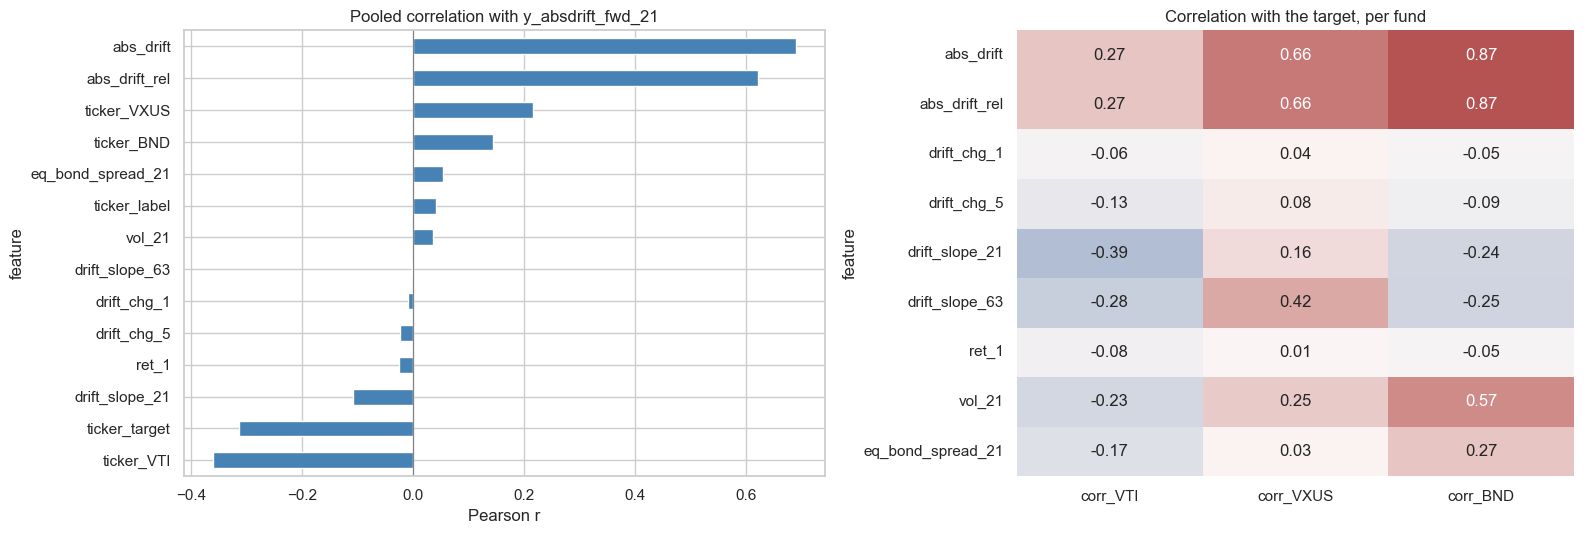

In [16]:
plot_cols = [c for c in FEATURES if report.loc[c, 'n_unique'] > 1]
corr_by_fund = report.loc[plot_cols, ['corr_VTI', 'corr_VXUS', 'corr_BND']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5),
                         gridspec_kw={'width_ratios': [1.15, 1]})

report.loc[plot_cols, 'corr_with_target'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(0, color='grey', linewidth=0.8)
axes[0].set_title(f'Pooled correlation with {TARGET}')
axes[0].set_xlabel('Pearson r')

sns.heatmap(corr_by_fund.dropna(how='all'), annot=True, fmt='.2f', cmap='vlag',
            vmin=-1, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title('Correlation with the target, per fund')

fig.tight_layout()
plt.show()

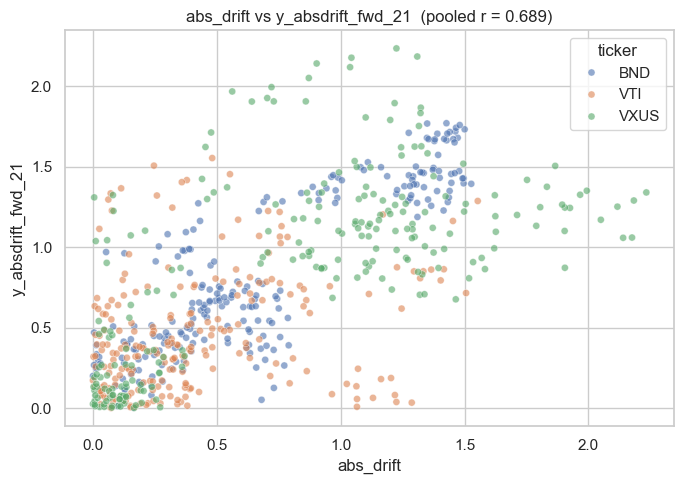

In [17]:
# The single strongest relationship, drawn rather than tabulated.
best = report['corr_with_target'].abs().idxmax()
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=matrix.dropna(subset=[best, TARGET]),
                x=best, y=TARGET, hue='ticker', alpha=0.6, s=26, ax=ax)
ax.set_title(f'{best} vs {TARGET}  (pooled r = {report.loc[best, "corr_with_target"]:.3f})')
fig.tight_layout()
plt.show()

**What the check says, feature by feature.**

| Feature | pooled r | per-fund | reading |
|---|---|---|---|
| `abs_drift` | +0.689 | BND +0.87, VXUS +0.66, VTI +0.27 | Strong, and strongest where the trend is strongest. Mostly restating the trend. |
| `abs_drift_rel` | +0.621 | identical per fund | Same information within a fund; the difference is cross-fund, and section 3 showed it wins outright against a relative target (0.906). |
| `drift_chg_1` | -0.010 | all under 0.06 | **Essentially zero.** Reported rather than quietly dropped: see below. |
| `drift_slope_21` | -0.108 | VTI -0.39, BND -0.24 | Weak pooled, real per fund, and *negative*: a steepening trend now is followed by a smaller drift in a month. |
| `vol_21` | +0.036 | **BND +0.57, VTI -0.23** | The pooled number is a lie by averaging. This is the clearest case for one-hot. |
| `eq_bond_spread_21` | +0.054 | BND +0.27, VTI -0.17 | Same pattern, weaker. |
| one-hot `ticker` | -0.36 / +0.22 / +0.14 | n/a | Three distinct signals. |
| `ticker_label` | +0.042 | n/a | The same information collapsed onto one line and averaged away. |
| `ticker_freq` | NaN | n/a | Constant. Cannot correlate with anything. |
| `close_was_filled` | NaN | n/a | Constant on this pull, by construction. |

**The one that did not work, stated plainly.** Stage 08's written instruction put the
first difference of drift at the top of the feature list. Its correlation with the
target is -0.010, which is nothing. The reasoning was sound and the result is still
negative: a one-day change is almost entirely noise at a 21-day horizon, and the
information Stage 08 was pointing at lives in the *smoothed* rate, `drift_slope_21`, not
the raw one. Recording that is more useful than deleting the feature and pretending the
prediction was never made.

**The most important row is `vol_21`.** Pooled it looks dead at +0.036. Per fund it is
+0.567 for BND and -0.227 for VTI. A model without the fund identity would see the
pooled number, conclude volatility is irrelevant, and be wrong twice over. That is the
concrete payoff of section 7's encoding choice, and it is why correlation is a hint
rather than a ranking.

## 10. What Stage 08's own gate rejects

`flag_columns` from `src/eda.py` was written in Stage 08 to catch columns that need a
decision before this stage. Running it on this stage's output is the test of whether it
was worth writing.

In [18]:
gate = flag_columns(matrix[FEATURES])
print(gate.to_string(index=False) if not gate.empty
      else 'nothing flagged at the default thresholds')
print()
print('columns that are constant (the check flag_columns misses):')
constant = [c for c in FEATURES if matrix[c].nunique(dropna=True) <= 1]
print('  ', constant or 'none')

        column              issue  value  threshold
drift_slope_63   high missingness   24.7      20.00
   ticker_freq near-zero variance    0.0       0.01

columns that are constant (the check flag_columns misses):
   ['ticker_freq', 'close_was_filled']


**What?** Two columns flagged. `drift_slope_63` for missingness at 24.70% against the
20% gate, and `ticker_freq` for near-zero variance at a coefficient of variation of 0.0.
A third problem column, `close_was_filled`, is **not** flagged.

**So what?** Two things, one about the data and one about the tool.

`drift_slope_63` costs 62 rows per fund, a quarter of the panel, and buys a pooled
correlation of -0.001. It fails the gate and does not earn an exception, so it is
dropped. `drift_slope_21` costs 8% and carries the same idea.

The tool worked, and its one blind spot is now visible. `flag_columns` finds constants
through a coefficient of variation, `std / |mean|`. `ticker_freq` is constant at 0.3333,
so its cv is 0.0 and it is caught. `close_was_filled` is constant at *zero*, and the
function skips any column whose mean is zero to avoid dividing by it, so it is missed.
The blind spot is narrow and precise: all-zero columns only. That is why
`feature_report` reports `n_unique` directly and why the cell above checks separately.
Stage 08's helper is not wrong; naming its edge case is cheaper than being surprised by
it in Stage 10.

**Now what?** The modelling set drops `drift_slope_63`, `ticker_freq`, `ticker_label`
and `close_was_filled`, and keeps the rest.

In [19]:
MODEL_FEATURES = ['abs_drift', 'abs_drift_rel', 'drift_chg_1', 'drift_chg_5',
                  'drift_slope_21', 'ret_1', 'vol_21', 'eq_bond_spread_21',
                  'ticker_VTI', 'ticker_VXUS', 'ticker_BND']
dropped = sorted(set(FEATURES) - set(MODEL_FEATURES))
print('kept   :', len(MODEL_FEATURES))
for c in MODEL_FEATURES:
    print('   ', c)
print('dropped:', dropped)

kept   : 11
    abs_drift
    abs_drift_rel
    drift_chg_1
    drift_chg_5
    drift_slope_21
    ret_1
    vol_21
    eq_bond_spread_21
    ticker_VTI
    ticker_VXUS
    ticker_BND
dropped: ['close_was_filled', 'drift_slope_63', 'ticker_freq', 'ticker_label', 'ticker_target']


## 11. The look-ahead test

Every feature here claims to be causal: the value at row *t* uses only rows at or before
*t*. That claim is worth more than an assertion in a docstring, because a leaked feature
does not raise an error. It raises an R-squared, which is why leaks survive until
somebody trusts the model.

`assert_no_lookahead` builds the features on the full history, builds them again on the
history truncated partway, and compares the overlapping rows. A causal feature is
identical in both.

In [20]:
def build_all(price_frame):
    """Full feature build from prices alone. Pure: no globals, no mutation."""
    tickers = list(TARGET_WEIGHTS)
    w = price_frame.pivot(index='date', columns='ticker', values='close')[tickers]
    tg = np.array([TARGET_WEIGHTS[t] for t in tickers])
    sh = (1_000_000 * tg) / w.iloc[0].to_numpy()
    v = w.to_numpy() * sh
    wd = pd.DataFrame(v / v.sum(axis=1, keepdims=True), index=w.index, columns=tickers)
    dl = ((wd - tg) * 100).reset_index().melt(id_vars='date', var_name='ticker',
                                              value_name='drift_pp')
    out = F.drift_features(dl, TARGET_WEIGHTS, slope_windows=(21, 63))
    out = out.merge(F.volatility_feature(price_frame, window=21)[
        ['date', 'ticker', 'ret_1', 'vol_21']], on=['date', 'ticker'], how='left')
    out = out.merge(F.equity_bond_spread(price_frame, TARGET_WEIGHTS, window=21),
                    on='date', how='left')
    return F.encode_ticker(out, 'onehot')


result = F.assert_no_lookahead(build_all, prices, MODEL_FEATURES)
print('PASSED')
for k, v in result.items():
    print(f'  {k:<18} {v}')

PASSED
  cut_date           2026-05-12 00:00:00
  rows_compared      528
  features_checked   11


In [21]:
# A test that never fails is not a test. Break one feature on purpose and confirm the
# assertion catches it. A CENTRED rolling window is the classic leak: it looks like an
# ordinary smoother and quietly reads the future.
def build_leaky(price_frame):
    out = build_all(price_frame)
    out['drift_slope_21'] = (out.groupby('ticker')['drift_pp']
                                .transform(lambda s: s.rolling(21, center=True).mean()))
    return out


try:
    F.assert_no_lookahead(build_leaky, prices, ['drift_slope_21'])
    print('NOT CAUGHT - the test is broken')
except AssertionError as exc:
    print('caught, as it should be:')
    print(' ', exc)

caught, as it should be:
  look-ahead detected in 'drift_slope_21': truncating the future changed which past rows are even defined (30 NaN with the full history, 60 without it). A window that needs rows after t is not causal.


**What?** The real build passes across 528 overlapping rows. The deliberately leaky
version, which changes one right-aligned window to a centred one, is caught immediately,
and the message names the giveaway: truncating the future changed *which past rows are
even defined*. A centred 21-day window needs ten rows after `t` to produce a value at
`t`, so the last ten rows of the truncated build cannot be computed while the same rows
in the full build can. That difference is the leak, made visible.

**So what?** `center=True` is a one-word change that reads as a harmless smoothing
choice and lets every row see ten days into its own future. In Stage 10b it would
produce a test score that cannot be reproduced in production, and nothing in the code or
the output would look wrong. This is the check that makes the other ten features
trustworthy rather than merely plausible.

**Now what?** The same assertion runs in `project_pipeline.ipynb`, so a future change
that introduces a leak fails the run instead of improving the score.

## 12. Save and hand off

In [22]:
keep = ['date', 'ticker', 'drift_pp'] + FEATURES + [TARGET]
matrix[keep].to_csv(PROC / 'features_full.csv', index=False)

model_ready = matrix[['date', 'ticker'] + MODEL_FEATURES + [TARGET]].dropna()
model_ready.to_csv(PROC / 'features_model_ready.csv', index=False)
report.to_csv(PROC / 'feature_report.csv')
horizon_table.to_csv(PROC / 'target_horizon_choice.csv')

print('full matrix      :', matrix[keep].shape)
print('model ready      :', model_ready.shape,
      f'({len(matrix) - len(model_ready)} rows lost to windows and the forward target)')
print()
for p in sorted(PROC.glob('*.csv')):
    print(f'  {p.name:<32} {p.stat().st_size:>7} bytes')

full matrix      : (753, 20)
model ready      : (627, 14) (126 rows lost to windows and the forward target)

  feature_report.csv                  1001 bytes
  features_full.csv                 190268 bytes
  features_model_ready.csv          123940 bytes
  target_horizon_choice.csv            150 bytes


## Summary

### The six features, and where each came from

| # | Feature | Origin | Verdict |
|---|---|---|---|
| 1 | `abs_drift_rel` | Stage 07's open unit problem, sized by Stage 08 | Keep. Predicts a relative target at 0.906 against 0.689 for the pp version. |
| 2 | `drift_chg_1`, `drift_slope_21` | Stage 08: build the rate, not the level | Keep the slope. The raw difference correlates at -0.010 and is kept only as a recorded negative result. |
| 3 | `vol_21` | Stage 08's volatility clustering | Keep. +0.57 for BND, -0.23 for VTI. |
| 4 | `eq_bond_spread_21` | Stage 08 traced the drift to this spread | Keep. The only feature encoding a mechanism rather than a description. |
| 5 | one-hot `ticker` | Stage 08's 251/251/251 categorical profile | Keep. Frequency encoding is provably a constant here; label encoding invents an order. |
| 6 | `close_was_filled` | The README's own open item since Stage 06 | Build and keep in the pipeline, exclude from the model while it is constant. |

Dropped: `drift_slope_63` (24.7% missing, fails Stage 08's own gate, buys nothing),
`ticker_freq` (constant), `ticker_label` (superseded by one-hot),
`close_was_filled` (constant today).

### Assumptions and risks

| Assumption | Risk if wrong |
|---|---|
| A 21-trading-day horizon is the right question | Chosen on autocorrelation and on what gives the principal useful warning, not on a business requirement anyone has stated. A different horizon changes which features matter. |
| One year of daily data supports 11 features on 690 usable rows | Roughly 63 rows per feature. Enough for a regularised linear model, not for anything with high capacity. Stage 10 should stay simple. |
| Correlation is a useful screen | It is linear and pairwise. `vol_21` pooled at +0.036 while being +0.57 within a fund is this stage's own demonstration of the limit. |
| The trend that makes drift predictable will continue | The same caveat as Stage 08. The features describe a trending regime, and a mean-reverting one would degrade all of them together. |
| Percentage points are the unit the policy is written in | Section 3 gives evidence the relative unit is more coherent. Still the principal's decision, still open. |

### For Stage 10

Use `data/processed/features_model_ready.csv`: 11 features, one target, complete rows
only. Split **chronologically**, as Stage 08 required, and expect the score to look
worse than a random split would give, because a random split on a trended series leaks.

Scale inside the split, never before it. Fitting a scaler on the full frame is the same
class of error as the centred window in section 11, and `assert_no_lookahead` will not
catch it because it happens after the features are built.